# Tutorial de Geração de Números Aleatórios Manual

Este notebook apresenta técnicas de amostragem de diferentes distribuições **sem** utilizar bibliotecas prontas, usando um Gerador Linear Congruencial (LCG) como base. Vamos demonstrar como gerar distribuições uniforme, normal, exponencial, Bernoulli, binomial e Poisson, com explicações passo a passo.

## 1. Implementando o Gerador Linear Congruencial (LCG)

O LCG é definido pela relação recursiva:

$$X_{n+1} = (a X_n + c) \bmod m$$

- $m$: módulo
- $a$: multiplicador
- $c$: incremento
- $X_0$: semente

Ele produz inteiros em $[0, m-1]$. Para obter valores em $[0,1)$, dividimos por $m$.

In [ ]:
class LCG:
    def __init__(self, seed=1, a=1664525, c=1013904223, m=2**32):
        self.state = seed
        self.a = a
        self.c = c
        self.m = m

    def random(self):
        """Retorna um flutuante em [0,1)."""
        self.state = (self.a * self.state + self.c) % self.m
        return self.state / self.m

# Testando o LCG
rng = LCG(seed=12345) # random number generator
print(rng.random(), rng.random(), rng.random())

0.02040268573909998 0.01654784823767841 0.5431557944975793


## 2. Distribuição Uniforme Contínua

Para gerar um valor uniforme no intervalo $[low, high)$, basta aplicar uma transformação linear:

$$U = low + (high - low) \times U_0$$

Onde $U_0$ é o valor retornado pelo LCG.

In [2]:
def uniform(rng, low=0.0, high=1.0):
    return low + (high - low) * rng.random()

# Exemplo: 5 valores em [10,20)
rng = LCG(seed=42)
print([uniform(rng, 10, 20) for _ in range(5)])

[12.523451747838408, 10.881250454112887, 15.772811982315034, 12.22554265987128, 13.756601971108466]


## 3. Distribuição Exponencial (Transformação Inversa)

Usamos o método da inversão: se $U\sim \mathrm{Uniform}(0,1)$,

$$X = -\frac{1}{\lambda} \ln(1 - U)$$

In [3]:
import math

def exponential(rng, lam=1.0):
    u = rng.random()
    return -math.log(1 - u) / lam

# Exemplo: 5 valores com lambda=2
rng = LCG(seed=2021)
print([exponential(rng, lam=2.0) for _ in range(5)])

[0.00975016481209761, 0.4468688659706271, 0.47719384458189773, 0.32498867788077557, 0.18726260051920857]


## 4. Distribuição Normal (Box–Muller)

Para obter duas amostras independentes padrão Normais:

$$Z_1 = \sqrt{-2 \ln U_1} \cos(2\pi U_2)$$
$$Z_2 = \sqrt{-2 \ln U_1} \sin(2\pi U_2)$$

In [4]:
import math

def normal(rng, mu=0.0, sigma=1.0):
    u1, u2 = rng.random(), rng.random()
    z0 = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)
    return mu + sigma * z0

# Exemplo: 5 valores N(0,1)
rng = LCG(seed=31415)
print([normal(rng) for _ in range(5)])

[-0.10588121975042804, -0.3709733994410376, 1.2703555250034408, -1.2088313916696334, -0.31326091852460886]


## 5. Distribuições Discretas

### Bernoulli

Retorna 1 com probabilidade $p$, 0 caso contrário.

In [5]:
def bernoulli(rng, p=0.5):
    return 1 if rng.random() < p else 0

# Exemplo: 10 amostras Bernoulli(p=0.3)
rng = LCG(seed=7)
print([bernoulli(rng, p=0.3) for _ in range(10)])

[1, 0, 0, 0, 1, 0, 0, 1, 1, 0]


### Binomial

Soma de $n$ variáveis Bernoulli($p$).

In [6]:
def binomial(rng, n, p):
    return sum(bernoulli(rng, p) for _ in range(n))

# Exemplo: Binomial(10, 0.4)
rng = LCG(seed=99)
print([binomial(rng, 10, 0.4) for _ in range(5)])

[7, 2, 5, 3, 3]


### Poisson (Método de Knuth)

Para gerar $X\sim \mathrm{Pois}(\lambda)$:

1. Defina $L = e^{-\lambda}$
2. Conte $k=0$, $p=1$
3. Enquanto $p > L$: incremente $k$, gere $u\sim U(0,1)$, e faça $p \leftarrow p\times u$
4. Retorne $k-1$.

In [7]:
def poisson(rng, lam):
    L = math.exp(-lam)
    k = 0
    p = 1.0
    while p > L:
        k += 1
        p *= rng.random()
    return k - 1

# Exemplo: Poisson(lambda=3)
rng = LCG(seed=2025)
print([poisson(rng, 3) for _ in range(10)])

[0, 5, 6, 3, 0, 4, 5, 1, 1, 2]


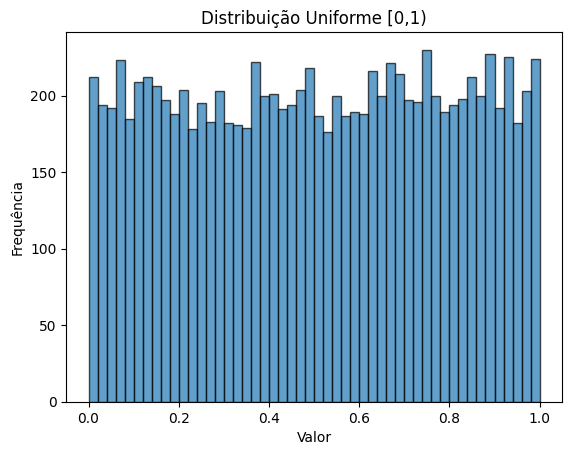

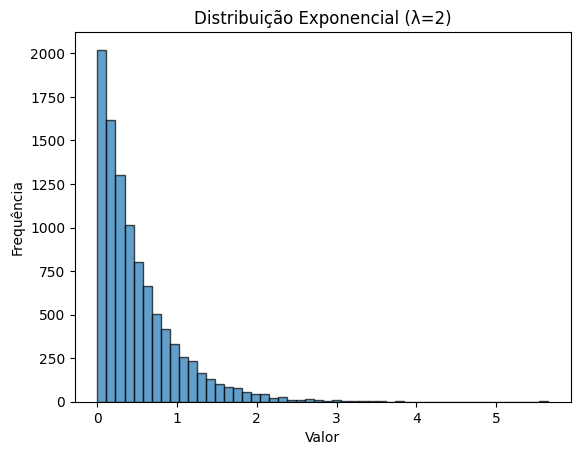

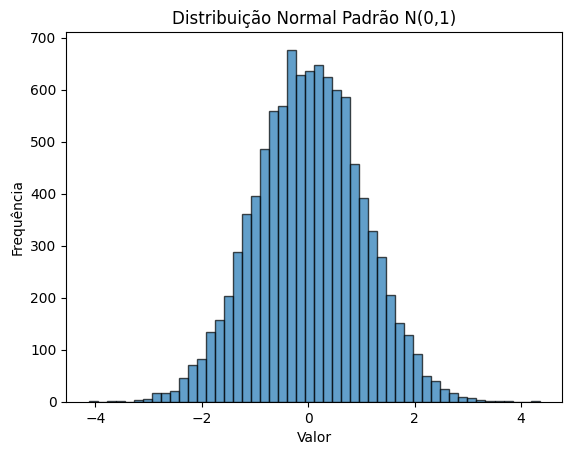

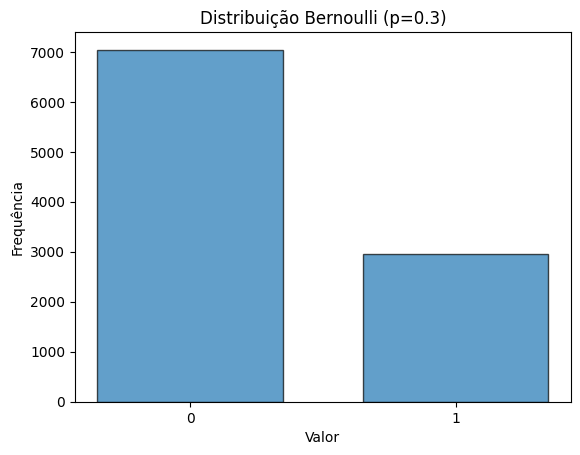

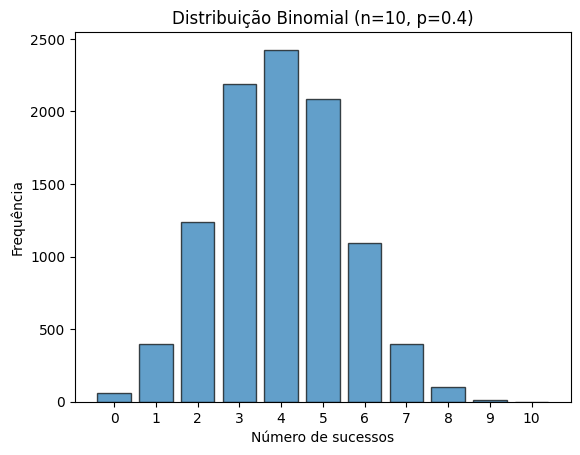

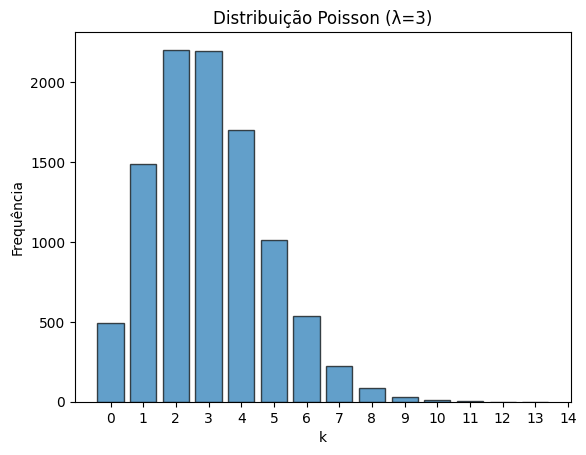

In [ ]:
# Visualizações das distribuições geradas manualmente
import matplotlib.pyplot as plt

# 1. Uniforme
rng = LCG(seed=42)
uniform_samples = [uniform(rng, 0, 1) for _ in range(10000)]
plt.hist(uniform_samples, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribuição Uniforme [0,1)')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

# 2. Exponencial
rng = LCG(seed=2021)
exp_samples = [exponential(rng, lam=2.0) for _ in range(10000)]
plt.hist(exp_samples, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribuição Exponencial (λ=2)')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

# 3. Normal (Box-Muller)
rng = LCG(seed=31415)
normal_samples = [normal(rng) for _ in range(10000)]
plt.hist(normal_samples, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribuição Normal Padrão N(0,1)')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

# 4. Bernoulli
rng = LCG(seed=7)
bernoulli_samples = [bernoulli(rng, p=0.3) for _ in range(10000)]
plt.hist(bernoulli_samples, bins=[-0.5,0.5,1.5], edgecolor='black', alpha=0.7, rwidth=0.7)
plt.title('Distribuição Bernoulli (p=0.3)')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.xticks([0,1])
plt.show()

# 5. Binomial
rng = LCG(seed=99)
binomial_samples = [binomial(rng, 10, 0.4) for _ in range(10000)]
plt.hist(binomial_samples, bins=range(12), edgecolor='black', alpha=0.7, align='left', rwidth=0.8)
plt.title('Distribuição Binomial (n=10, p=0.4)')
plt.xlabel('Número de sucessos')
plt.ylabel('Frequência')
plt.xticks(range(11))
plt.show()

# 6. Poisson
rng = LCG(seed=2025)
poisson_samples = [poisson(rng, 3) for _ in range(10000)]
plt.hist(poisson_samples, bins=range(15), edgecolor='black', alpha=0.7, align='left', rwidth=0.8)
plt.title('Distribuição Poisson (λ=3)')
plt.xlabel('k')
plt.ylabel('Frequência')
plt.xticks(range(15))
plt.show()

## Conclusão

Neste tutorial vimos como implementar manualmente métodos de amostragem para várias distribuições sem depender de bibliotecas prontas.